In [1]:
specfn = '/orange/adamginsburg/jwst/cloudc/spectra/J110621_JWST_NIRSpec_FS_spectrum_McClure23.txt'

In [2]:
!head -n 13 $specfn

;;; JWST NIRSpec FS spectrum of J110621.
;;;
;;; Reduced by Klaus Pontoppidan using the STScI JWST
;;; pipeline detector level 1 processing using version 1.7.1, 
;;; Calibration Reference Data System (CRDS) context
;;; jwst_0948.pmap, and the PUB CRDS server. 
;;;
;;; Published in McClure et al. (2023), Nature Astronomy.
;;; Full observational and data reduction details given 
;;; in the Methods section of that publication.
;;;
;;; Wavelength (micron), Flux (mJy), u_Flux (mJy)
       2.7388065     0.017442079    0.0029359214


In [3]:
from astropy.table import Table
from astropy import units as u
spectable = Table.read(specfn, format='ascii', comment=';',)
spectable.rename_column('col1', 'wavelength')
spectable['wavelength'].unit = u.um
spectable.rename_column('col2', 'flux')
spectable['flux'].unit = u.mJy

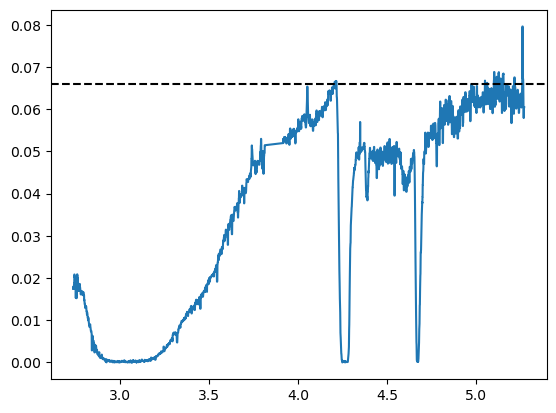

In [4]:
import pylab as pl
pl.plot(spectable['wavelength'], spectable['flux']);
pl.axhline(0.066, color='k', linestyle='--');

3.741200676330253e+18 1 / cm2 41.15320743963278 1 / cm


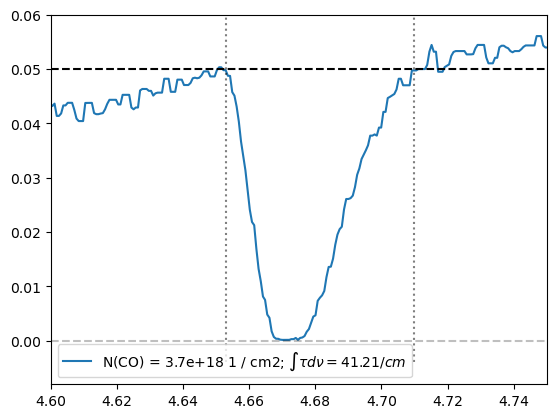

In [6]:
import numpy as np
import pylab as pl
cont = 0.050
lam_min, lam_max = 4.653, 4.71
freq = spectable['wavelength'].to(u.cm**-1, u.spectral())
dnu = np.abs(np.diff(freq))

A = 1.1e-17*u.cm

sel = (spectable['wavelength'] > lam_min*u.um) & (spectable['wavelength'] < lam_max*u.um)
tau = np.log((cont*u.mJy / spectable['flux'])) 
inttaudnu = (dnu[sel[:-1]] * tau[sel]).sum().to(u.cm**-1)
N = (inttaudnu / A).to(u.cm**-2)
print(N, inttaudnu)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.legend(loc='lower left')
pl.xlim(4.6, 4.75);
pl.ylim(-0.008, 0.06);

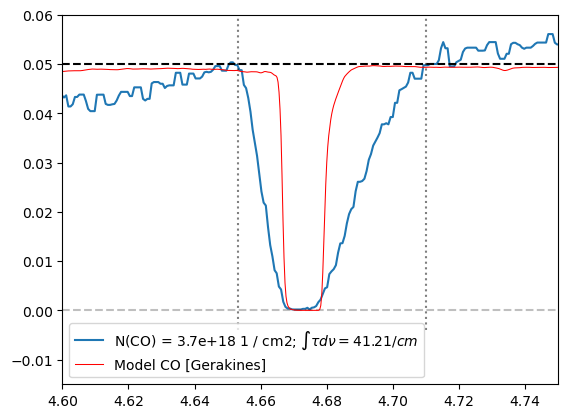

In [7]:
from icemodels.core import absorbed_spectrum, retrieve_gerakines_co, read_lida_file, read_ocdb_file, optical_constants_cache_dir
co_gera = retrieve_gerakines_co()
xarr = np.linspace(4.6, 4.75, 500)*u.um
yarr = np.ones(xarr.size) * cont
absspec = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=co_gera)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.plot(xarr, absspec, color='r', linewidth=0.75, label='Model CO [Gerakines]');
pl.legend(loc='lower left')
pl.xlim(4.6, 4.75);
pl.ylim(-0.015, 0.06);

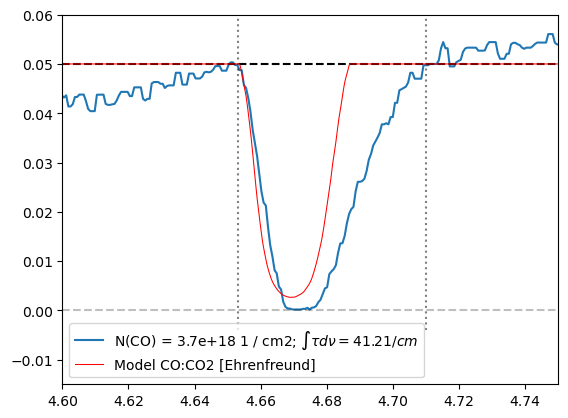

In [9]:
coco2 = read_lida_file(f'{optical_constants_cache_dir}/60_CO:CO2_1:1_25.0K.txt')

xarr = np.linspace(4.6, 4.75, 500)*u.um
yarr = np.ones(xarr.size) * cont
absspec = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=coco2)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.plot(xarr, absspec, color='r', linewidth=0.75, label='Model CO:CO2 [Ehrenfreund]');
pl.legend(loc='lower left')
pl.xlim(4.6, 4.75);
pl.ylim(-0.015, 0.06);

In [18]:
coco2[(coco2['Wavelength'] > 4.6*u.um) & (coco2['Wavelength'] < 4.75*u.um)][::100]

Wavenumber,k,Wavelength
1 / cm,,um
float64,float64,float64
2105.3,-0.02436,4.7499168764546615
2117.35,-0.0234,4.722884737997969
2129.41,-0.01997,4.696136488510902
2141.46,0.3982,4.669711318446294
2153.52,-0.02171,4.6435603105613135
2165.57,-0.02392,4.617721893081267


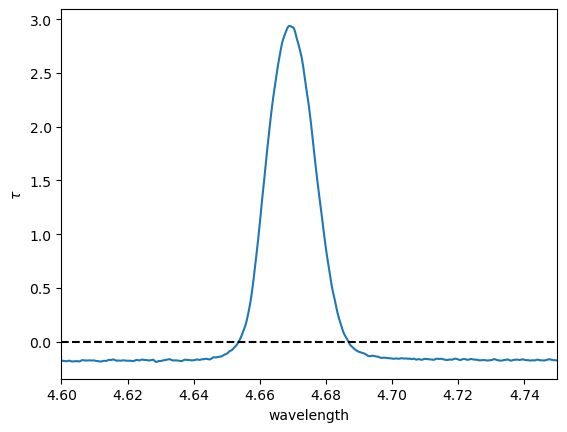

In [10]:
#pl.plot(coco2['Wavelength'], coco2['k'])
pl.plot(xarr, absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=coco2, return_tau=True))
pl.xlim(4.6, 4.75);
pl.ylabel('$\\tau$')
pl.xlabel("wavelength");
pl.axhline(0, linestyle='--', color='k');

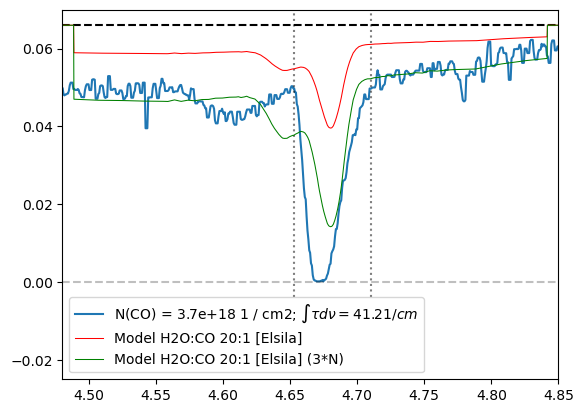

In [31]:
h2oco = read_ocdb_file(f'{optical_constants_cache_dir}/39_H2O:CO_(20:1)_12K_Elsila.txt')

cont = 0.066
xarr = np.linspace(4.48, 4.85, 1500)*u.um
yarr = np.ones(xarr.size) * cont
absspec = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=h2oco)
absspec2 = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N*3, ice_model_table=h2oco)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.plot(xarr, absspec, color='r', linewidth=0.75, label='Model H2O:CO 20:1 [Elsila]');
pl.plot(xarr, absspec2, color='g', linewidth=0.75, label='Model H2O:CO 20:1 [Elsila] (3*N)');
pl.legend(loc='lower left')
pl.xlim(4.48, 4.85);
pl.ylim(-0.025, 0.07);

In [ ]:
from icemodels import fluxes_in_filters

from astroquery.svo_fps import SvoFps
jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')

filter_ids = ['JWST/NIRCam.F410M', 'JWST/NIRCam.F466N', 'JWST/NIRCam.F356W', 
             'JWST/NIRCam.F444W', 'JWST/NIRCam.F405N']
filter_data = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in filter_ids}
transdata = {fid: SvoFps.get_transmission_data(fid) for fid in filter_ids}

cmd_x = ('JWST/NIRCam.F410M',
         'JWST/NIRCam.F466N',
         'JWST/NIRCam.F356W',
         'JWST/NIRCam.F444W',
         'JWST/NIRCam.F405N',
         )
flxd = fluxes_in_filters(spectable['wavelength'], spectable['flux'], filterids=cmd_x, transdata=transdata)

In [ ]:
flxd

In [ ]:
%run /orange/adamginsburg/jwst/brick/analysis/iceage_fluxes.py
iceage_mags